##### ***长短期记忆网络(LSTM)***
###### 长期以来，隐变量模型都存在着长期记忆保存和短期输入缺失（无效输入）问题。最早解决它们的方法是LSTM，它和GRU有着相似的设计，但是LSTM的结构更复杂，并且诞生时间更早。它的灵感来自于计算机的逻辑门，LSTM引入了记忆元或简称单元（cell），其作用于GRU类似。为控制记忆元，我们需要很多门，分为三种：<br>1. 输出门：为了从单元中输出条目。<br>2. 输入门：为了决定何时将数据读入单元。<br>3. 遗忘门：来重置单元中的内容。
##### ***输入门、遗忘门、输出门***
###### 如GRU一样，LSTM中将当前时间步的输入和上一个时间步的隐状态作为数据输入LSTM的门中，且都通过sigmoid函数控制值的范围在（0，1）之间。
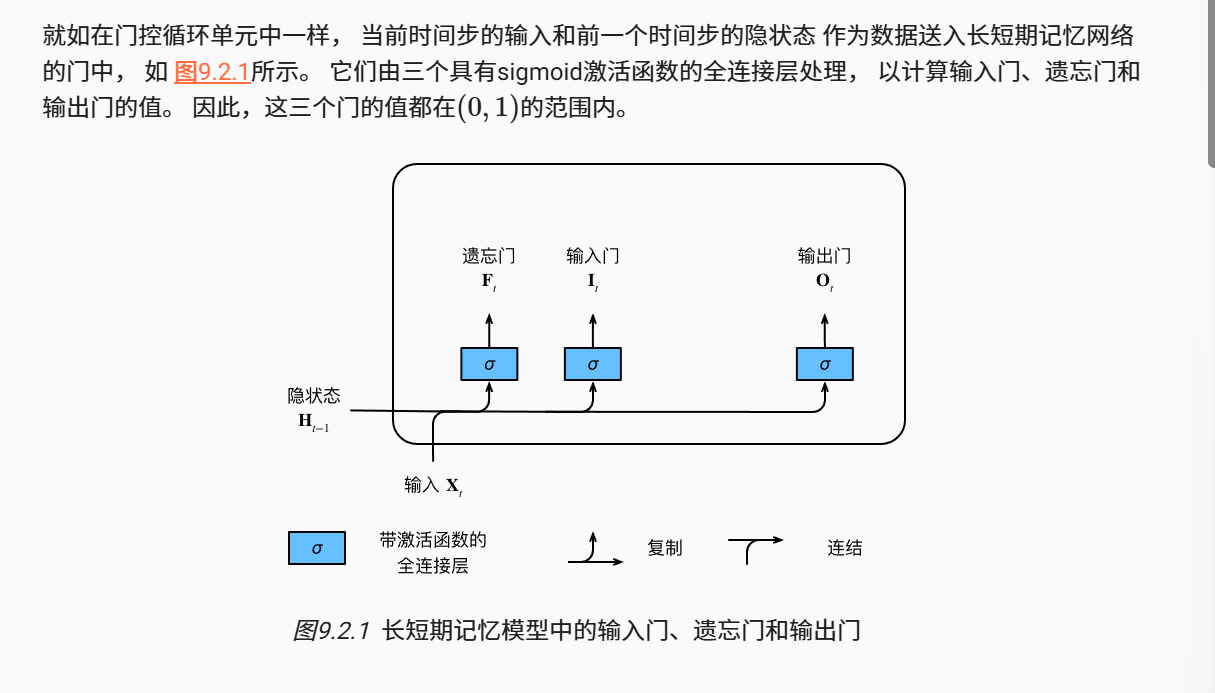
###### 具体数学表达如下：
$$I_t = \sigma(X_tW_{xi} + H_{t-1}W_{hi}) + b_i,\\
F_t = \sigma(X_tW_{xf} + H_{t-1}W_{hf}) + b_f,\\
O_t = \sigma(X_tW_{xo} + H_{t-1}W_{ho}) + b_o,\\
$$
###### 其中$W_{xi}$、$W_{xf}$、$W_{xo}$、$W_{hi}$、$W_{hf}$、$W_{ho}$分别是输入门、遗忘门、输出门的权重矩阵。
##### ***候选记忆元***
###### 类似的，LSTM中也有候选记忆元$\tilde{C_t}\in \mathbb{R}^{n\times h}$，它的计算与上述三个门的计算类似，区别在于它使用了tanh函数。函数值的范围在（-1，1）之间。
$$\tilde{C_t} = tanh(X_tW_{xc} + H_{t-1}W_{hc}) + b_c,$$
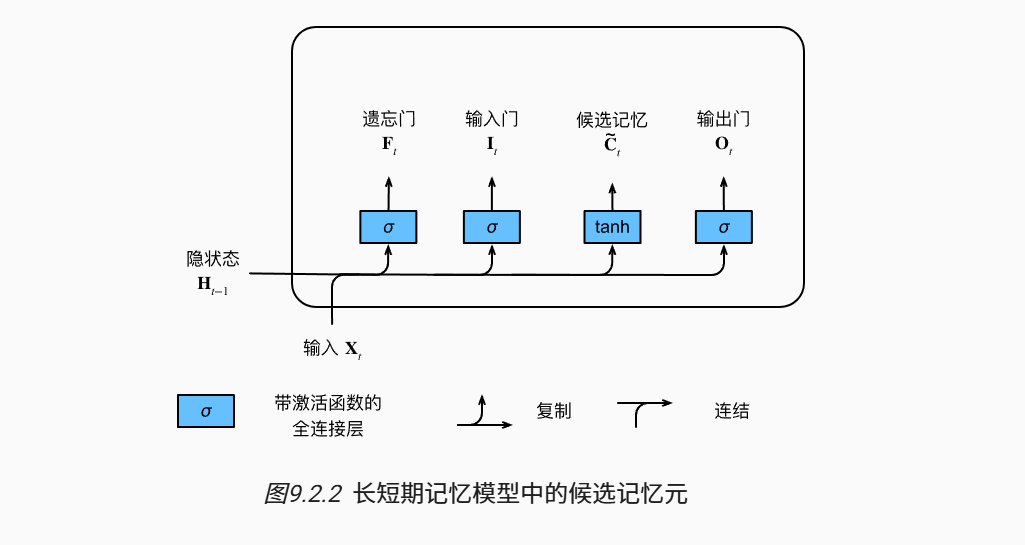
##### ***记忆元***
###### 在GRU中，有一种机制来控制输入或者遗忘。类似的，LSTM中也有两个门用于这个目的：输入门$I_t$控制“采用多少来自$\tilde{C_t}$的新数据”，而遗忘门$F_t$控制“保留多少来自过去$\tilde{C_{t-1}}$的数据”。具体公式如下：
$$C_t = F_t\odot C_{t-1} + I_t\odot \tilde{C_t}$$
###### 如果遗忘门始终为1且输入门始终为0，那么过去的记忆元会一直被保留并被传递到当前时间步。
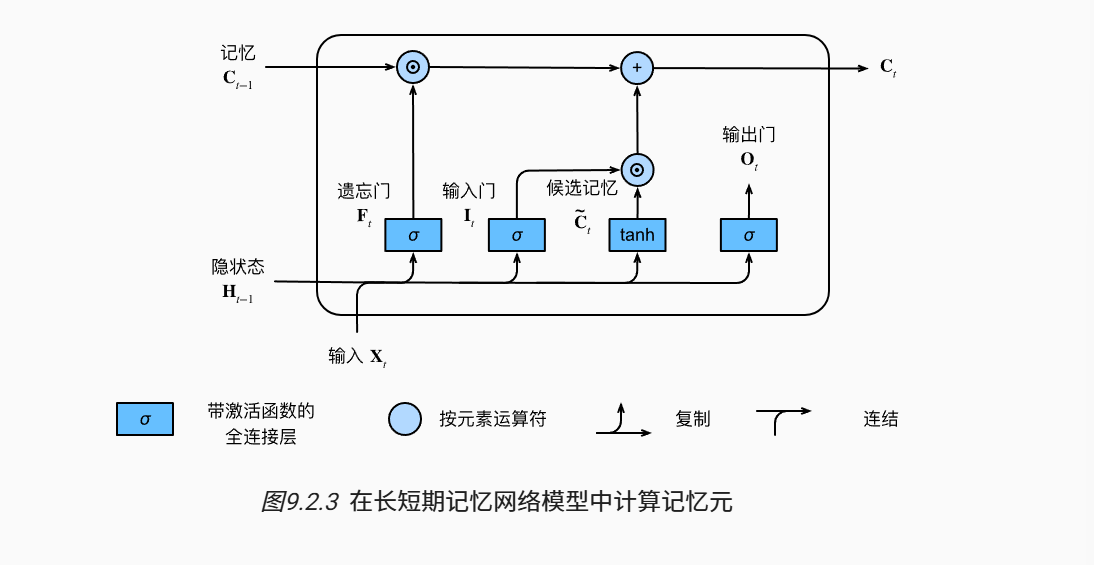
##### ***隐状态***
###### 刚刚谈论的是LSTM中的新元素记忆元，而关于隐状态如何与记忆元结合起来仍需考虑。LSTM中有三种门，上述只提到了输入门和遗忘门，而输出门此时用于控制隐状态是否更新：
$$H_t = O_t\odot tanh(C_t)$$
###### 只要输出门接近1，我们就能有效的将记忆信息转递给预测部分，而对应输出门接近0，我们只保留记忆元内的信息，而不用更新隐状态。

In [17]:
import torch
from torch import nn
from d2l import torch as d2l

batch_size, num_steps = 32, 35
train_iter, vocab = d2l.load_data_time_machine(batch_size, num_steps)

In [ ]:
def get_lstm_params(vocab_size, num_hiddens, device):
    num_inputs = num_outputs = vocab_size

    def normal(shape):
        return torch.randn(size=shape, device=device)*0.01

    def three():
        return (normal((num_inputs, num_hiddens)),
                normal((num_hiddens, num_hiddens)),
                torch.zeros(num_hiddens, device=device))

    W_xi, W_hi, b_i = three() # 输入门参数
    W_xo, W_ho, b_o = three() # 输出门参数
    W_xc, W_hc, b_c = three() # 候选记忆元参数
    W_xf, W_hf, b_f = three() # 遗忘门参数

    W_hq = normal((num_hiddens, num_outputs))
    b_q = torch.zeros(num_outputs, device=device)

    params = [W_xi, W_hi, b_i, W_xo, W_ho, b_o, W_xc, W_hc, b_c, W_xf, W_hf, b_f, W_hq, b_q]

    for param in params:
        param.requires_grad = True
        
    return params


In [19]:
def init_lstm_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device),
            torch.zeros((batch_size, num_hiddens), device=device))

In [20]:
def lstm(inputs, state, params):
    [W_xi, W_hi, b_i, W_xo, W_ho, b_o, W_xc, W_hc, b_c, W_xf, W_hf, b_f, W_hq, b_q] = params
    (H, C) = state
    outputs = []
    for X in inputs:
        I = torch.sigmoid((X @ W_xi) + (H @ W_hi) + b_i)
        F = torch.sigmoid((X @ W_xf) + (H @ W_hf) + b_f)
        O = torch.sigmoid((X @ W_xo) + (H @ W_ho) + b_o)
        C_tilda = torch.tanh((X @ W_xc) + (H @ W_hc) + b_c)
        C = F * C + I * C_tilda
        H = O * torch.tanh(C)
        Y = (H @ W_hq + b_q)
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (H, C)

perplexity 1.1, 19235.6 tokens/sec on cpu
time traveller praceeder as really plone to sedting of the inatm
traveller but you are wrong to saythat we cannot move about


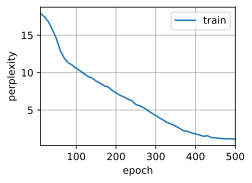

In [21]:
vocab_size, num_hiddens, device = len(vocab), 256, d2l.try_gpu()
num_epochs, lr = 500, 1
model = d2l.RNNModelScratch(len(vocab), num_hiddens, device, get_lstm_params, init_lstm_state, lstm)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

perplexity 1.0, 71486.2 tokens/sec on cpu
time travelleryou can show black is white by argument said filby
travelleryou can show black is white by argument said filby


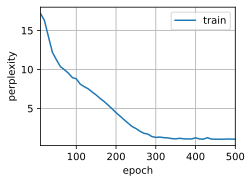

In [22]:
num_inputs = vocab_size
lstm_layer = nn.LSTM(num_inputs, num_hiddens)
model = d2l.RNNModel(lstm_layer, len(vocab))
model = model.to(device)
d2l.train_ch8(model, train_iter, vocab, lr, num_epochs, device)